In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
# pip install stepmix

In [4]:
myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')

/tmp/ipykernel_11850/3248146962.py:1: DtypeWarning: Columns (14,16,41,51,63,65,66,76,80,89,99,111,113,114,124,128) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [5]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'with vomiting', 'without foley catheter', 'without gangrene',
       'without hemodynamic compromise',
       'without return to pre-existing conscious level',
       'witnessed, < 15 minutes CPR', 'witnessed, > 15 minutes CPR',
       'wound dehiscence', 'wound infection', 'wound-associated'],
      dtype='object', length=2199)

In [6]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
# myFilter = (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])# & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(float) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

In [7]:
myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]
myXValue = myPredictorsDf.drop(columns= myColumns + [ 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
myXValue = myXValue.select_dtypes(exclude=['object'])
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastMGCSPositive', 'Hypothermia']], test_size=0.3)

In [8]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myXValue = myPredictorsDf.drop(columns= myColumns + [ 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue#[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
myXValue = myXValue.select_dtypes(exclude=['object'])
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['Hypothermia'])
myYValue = myPredictorsDf['DeathAtDischarge']
myYValue = myYValue.astype(int)
X_train_no_group, X_test_no_group, T_train, T_test, Y_train, Y_test = train_test_split(myNewXValue, myPredictorsDf['Hypothermia'], myYValue, test_size=0.3, stratify=myPredictorsDf[['DeathAtDischarge', 'Hypothermia']])
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=5, n_estimators=1000),  
    model_t= XGBClassifier(max_depth=5, n_estimators=1000),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
)
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]#, ('pca', PCA(n_components=0.95))]
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))


In [10]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())


In [ ]:
# myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
# X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
# X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())
# myNewXTrain.columns = X_train_no_group.columns
causal_forest.fit(Y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(Y_train, T_train, X=myNewXTrain))

# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
# myNewXTrain.columns = X_train_no_group.columns
CATE_pred = causal_forest.effect(myNewXTrain)

# print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

In [61]:
# causal_forest = causal_forest.tune(Y_train, T_train, X=myNewXTrain)

In [ ]:
# def policy_risk(y_0, y_1, predicted_ite, t):
#     """
#     Computes policy risk using observed outcomes.

#     Args:
#         y_0 (numpy array): Observed outcomes for control group (when T=0).
#         y_1 (numpy array): Observed outcomes for treated group (when T=1).
#         predicted_ite (numpy array): Model's predicted individual treatment effect.
#         t (numpy array): Treatment assignment (1 for treated, 0 for control).

#     Returns:
#         float: Estimated policy risk.
#     """
#     factual_outcomes = np.where(t == 1, y_1, y_0)
#     recommended_treatment = (predicted_ite > 0).astype(int)
#     expected_outcome = np.where(recommended_treatment == 1, y_1, y_0)
    
#     return np.mean(factual_outcomes - expected_outcome)

# # Example usage:
# y_0 = np.array([2.5, 3.0, 1.2, 4.0])  # Observed outcome under control
# y_1 = np.array([3.5, 4.0, 1.8, 5.0])  # Observed outcome under treatment
# t = np.array([0, 1, 0, 1])  # Treatment assignment
# predicted_ite = np.array([0.8, 0.5, -0.2, 0.9])  # Model's predicted ITE

# policy_risk_value = policy_risk(y_0, y_1, predicted_ite, t)
# print("Policy Risk:", policy_risk_value)


In [ ]:
causal_forest.summary()

In [29]:
myNewXTest = myPipeline.transform(X_test_no_group)
causal_forest.score(Y_test, T_test, myNewXTest)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.19714108009018969

In [77]:
myNewXTest = myPipeline.transform(X_train_no_group)
causal_forest.score(Y_train, T_train, myNewXTest)

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


0.18612241953044245

In [13]:
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')

In [14]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect'] = (myNewDf['predicted_effect'] > 0).astype(int)

NameError: name 'CATE_pred' is not defined

-0.034976201329659076
0.06257164522775097


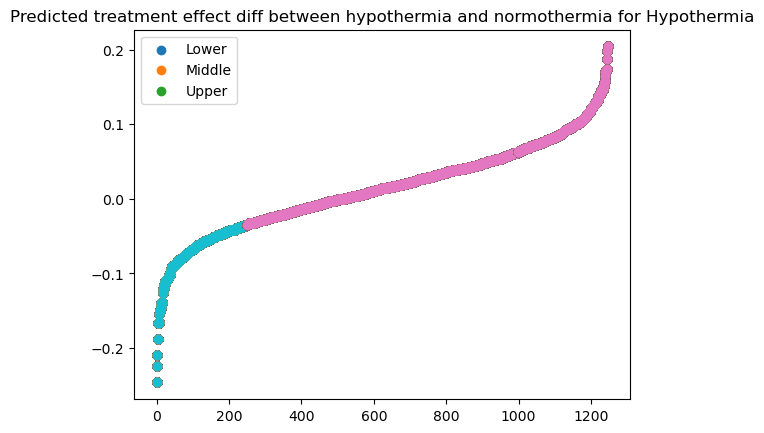

In [80]:
plotPredictedTreatmentEffect(myNewDf, 'Hypothermia')

In [18]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12', aGroup = 'groupe'):
    if X_train.shape[0] != y_train.shape[0]:
        raise Exception('Mismatch X and Y')
    if X_train.shape[0] != myNewDf.shape[0]:
        raise Exception('Mismatch group and X')
    myData = pd.concat([X_train, myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)
    
    myPvaluesNoInteraction = model1.summary()
    myPvalues = model2.summary()

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'No interaction {myPvaluesNoInteraction}')
    print(f'Interaction {myPvalues}')
    return p_value
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import f

def getTreatmentEffectDiff_regression(X_train, y_train, myNewDf, aCategory='CPC12', aGroup='groupe'):
    # Combine the relevant data into one DataFrame
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    myData = myData.rename(columns={y_train.name: aCategory})  # Ensure the target column is named consistently

    # Fit the reduced model (without interaction term)
    model1 = smf.ols(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    # Fit the full model (with interaction term)
    model2 = smf.ols(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    # Perform an F-test to compare the models
    f_stat = (model1.ssr - model2.ssr) / (model2.df_model - model1.df_model) / (model2.ssr / model2.df_resid)
    df_diff = model2.df_model - model1.df_model
    p_value = f.sf(f_stat, df_diff, model2.df_resid)

    print(f'Likelihood ratio of test results (F-test for regression):')
    print(f'F-statistic: {f_stat}')
    print(f'p-value: {p_value}')
    print(f'Degrees of freedom: {df_diff}')
    return p_value


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


-0.046929177102362836
0.04743544710131568
Optimization terminated successfully.
         Current function value: 0.653467
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.651950
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 3.142095411358696
p-value: 0.2078273263823032
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1036
Model:                          Logit   Df Residuals:                     1032
Method:                           MLE   Df Model:                            3
Date:                Mon, 17 Feb 2025   Pseudo R-squ.:                 0.01261
Time:                        16:48:58   Log-Likelihood:                -676.99
converged:                       True   LL-Null:                       -685.63
Covariance Type:            nonrobust   LLR p-value:        

0.2078273263823032

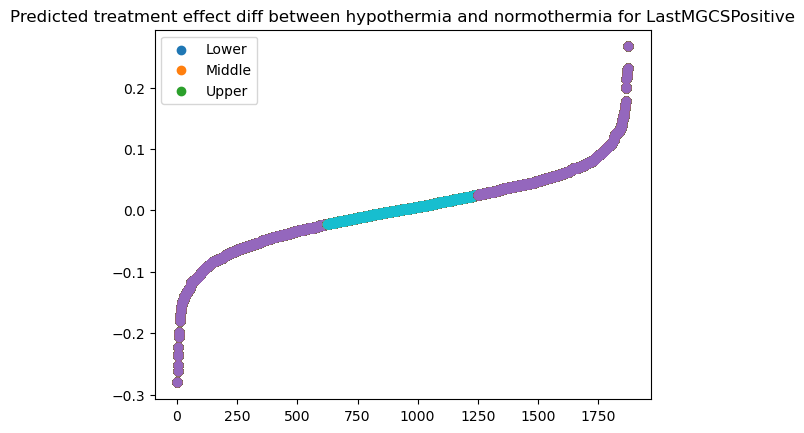

In [19]:
# getTreatmentEffectDiff_regression(X_train, myYValue, myNewDf, 'LastGCS', 'Hypothermia')
myNewXTest = myPipeline.transform(X_train_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect']
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, 'LastMGCSPositive')

# myNewDf['predicted_effect_group'] = CATE_pred[:, 0]


X_test_new = X_train_no_group.copy()
X_test_new['Hypothermia'] = T_train
getTreatmentEffectDiff(X_test_new, Y_train, myNewDf, 'LastMGCSPositive', 'Hypothermia')

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


Optimization terminated successfully.
         Current function value: 0.678745
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.678001
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.24113241674990604
p-value: 0.623389417494125
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  162
Model:                          Logit   Df Residuals:                      159
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Feb 2025   Pseudo R-squ.:                0.004967
Time:                        14:13:57   Log-Likelihood:                -109.96
converged:                       True   LL-Null:                       -110.51
Covariance Type:            nonrobust   LLR p-value:                    0.5776
                      

0.623389417494125

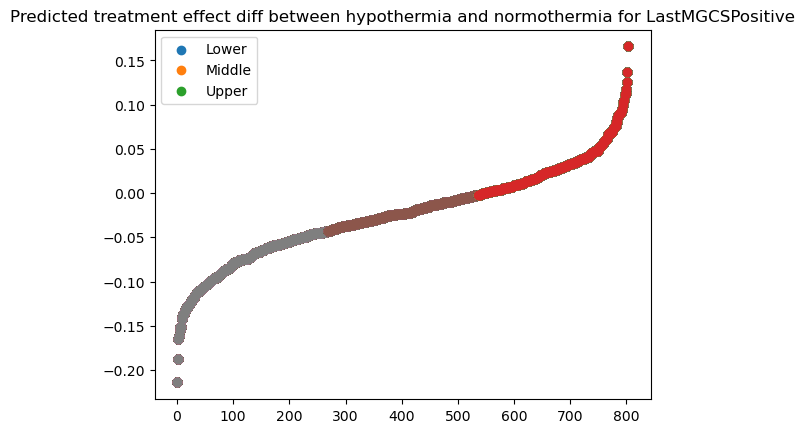

In [24]:
myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect_group'] = 'Middle'
# myNewDf.loc[myNewDf['predicted_effect'] > upper_third, 'predicted_effect_group'] = 'Upper'
# myNewDf.loc[myNewDf['predicted_effect'] < lower_third, 'predicted_effect_group'] = 'Lower'
plotPredictedTreatmentEffect(myNewDf, 'LastMGCSPositive')

X_test_new = X_test_no_group.copy()
X_test_new['Hypothermia'] = T_test
getTreatmentEffectDiff(X_test_new, Y_test, myNewDf, 'LastMGCSPositive', 'Hypothermia')

In [17]:
def getPredictedThirds(aDf):
    lower_third = aDf['predicted_effect'].quantile(1/5)
    upper_third = aDf['predicted_effect'].quantile(4/5)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1, 1, aDf
    aDf['predicted_effect_group'] = pd.cut(
        aDf['predicted_effect'],
        bins=[-float('inf'), lower_third, upper_third, float('inf')],
        labels=['Lower', 'Middle', 'Upper']
    )
    # aDf['predicted_effect_group'] = (aDf['predicted_effect'] > 0).astype(int)
    print(lower_third)
    print(upper_third)
    return lower_third, upper_third, aDf

In [382]:
myXValue

,gender,age,admissionheight,admissionweight,PEA,Asystole,VTachy,VFib,Hypothermia,FirstGCS,FirstMGCS,Lactate,Troponin,pH,Chloride
116,0,57,154.90,54.70,0,0,0,0,0,9,5,1.6,NaN,7.470,100.0
117,0,48,177.80,99.00,0,1,0,0,0,15,6,1.6,NaN,NaN,105.0
119,0,50,167.60,110.20,0,0,0,1,1,9,4,1.3,0.26,7.300,102.0
120,0,24,167.64,74.69,0,0,0,0,0,3,1,6.6,NaN,7.257,105.0
121,0,63,165.10,92.90,0,1,0,0,0,11,4,NaN,NaN,7.484,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,0,64,160.00,85.60,0,0,0,1,0,14,6,NaN,27.72,7.419,105.0
3393,0,69,182.90,127.80,0,0,0,0,0,3,1,0.9,NaN,7.277,105.0
3395,0,42,185.40,110.90,0,1,0,0,0,3,1,2.3,0.04,6.879,95.0
3402,0,82,162.60,61.40,1,0,0,0,1,10,6,10.6,0.22,7.302,106.0
